# AI スコアのスタイル露出（core ファクターベース）

`03_bax_results` で、AI スコア（`ens_lgbm_dnn`）は最適化の制約下でアルファが吸収され、BM 加重平均が +0.80 とサイズに寄っていることが分かった。
ここでは AI スコアが core ファクターの **スタイル**（`alpha/LIST.md` の core 表の定義: Stock Value / Flow Value / Profitability / Growth /
Shareholder Return / Momentum / Volatility / Financial Quality）にどれだけ寄っているかを、参照の `comp_ew` と比較して確認する。

**手順**

1. 各月ユニバース内で、core の各ファクターを Blom 正規スコアに変換（同順位は平均順位、欠損はそのまま）
2. スタイルスコア = スタイル構成ファクターの Blom スコアの平均（欠損は除く）→ 再 Blom 化。**符号はファクターの生の向きのまま**
   （例: Volatility は「ボラが高いほど高い」、Financial Quality はレバレッジ系と効率性系が混在するので符号の解釈に注意）
3. AI スコアとの関係を 4 つの見方で確認
   - 各スタイル・サイズ（log ユニバースウェイト）との月次 Spearman 相関
   - スタイル + サイズ + セクターへのクロスセクション回帰（R² の内訳、標準化ベータの Fama-MacBeth 平均と t 値）
   - 個別ファクターとの相関（上位 / 下位）
   - Q5（最上位 20%）ポートフォリオのスタイル露出（Q5 平均 − ユニバース平均、z 単位）
4. スタイル + サイズ + セクターで説明されない残差スコアの IC（AI の情報のうちスタイルに還元されない部分）

In [1]:
import re
import warnings

import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401  日本語ラベル用
import numpy as np
import pandas as pd
from scipy.stats import norm

from alphaeval import InputStore, forward_returns, ic_summary, information_coefficient, quantile_analysis

pd.set_option("display.width", 260)
pd.set_option("display.max_columns", 60)
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3})

INPUT_ROOT = "../../input/msci_india_imi"
SCORES = {"ens_lgbm_dnn": "my_ai/ens_lgbm_dnn", "ens_lgbm_dnn_hl1": "my_ai/ens_lgbm_dnn_hl1", "comp_ew": "composite/comp_ew", "comp_ew_70_ai_30": "composite/comp_ew_70_ai_30"}
MAIN = "ens_lgbm_dnn"
START, END = 201212, 202606
SECTOR_NAMES = {10: "エネルギー", 15: "素材", 20: "資本財", 25: "一般消費財", 30: "生活必需品", 35: "ヘルスケア", 40: "金融", 45: "情報技術", 50: "通信", 55: "公益", 60: "不動産"}

store = InputStore(INPUT_ROOT)

## 1. スタイル定義の読み込みと core ファクターのロード

In [2]:
text = open(f"{INPUT_ROOT}/alpha/LIST.md", encoding="utf-8").read()
core_section = text.split("## core", 1)[1].split("\n## ", 1)[0]
style_of = {}
for m in re.finditer(r"^\| `([a-z0-9_]+)` \| ([^|]+) \|", core_section, flags=re.M):
    factor, style = m.group(1), m.group(2).strip()
    if style and style != "-":
        style_of[factor] = style
styles = sorted(set(style_of.values()))
print(f"スタイル付きファクター {len(style_of)} 本、スタイル {len(styles)}: {styles}")

univ = store.universe(START, END)
log_size = np.log(univ.where(univ > 0))
gics = store.alpha("attributes/gics", START, END).reindex(columns=univ.columns)
sector = (gics // 1_000_000).where(univ.notna())

core = {}
for f in style_of:
    panel = store.alpha(f"core/{f}", START, END).reindex(index=univ.index, columns=univ.columns)
    core[f] = panel.where(univ.notna())
print(f"core ロード完了: {len(core)} 本、{univ.shape}")

スタイル付きファクター 100 本、スタイル 8: ['Financial Quality', 'Flow Value', 'Growth', 'Momentum', 'Profitability', 'Shareholder Return', 'Stock Value', 'Volatility']


core ロード完了: 100 本、(163, 942)


## 2. スタイルスコアの構築（Blom 正規化 → スタイル内平均 → 再 Blom 化）

In [3]:
def blom(df: pd.DataFrame) -> pd.DataFrame:
    ranks = df.rank(axis=1, method="average")
    n = df.notna().sum(axis=1)
    u = ranks.sub(3 / 8).div(n.add(1 / 4), axis=0)
    return pd.DataFrame(norm.ppf(u.to_numpy(dtype=float)), index=df.index, columns=df.columns)

core_z = {f: blom(p) for f, p in core.items()}
style_score = {}
for s in styles:
    members = [f for f, st in style_of.items() if st == s]
    stacked = np.stack([core_z[f].to_numpy() for f in members])
    with np.errstate(all="ignore"), warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)  # 全ファクター欠損の銘柄は NaN のまま
        avg = np.nanmean(stacked, axis=0)
    style_score[s] = blom(pd.DataFrame(avg, index=univ.index, columns=univ.columns))
style_score["Size (log cap)"] = blom(log_size.where(univ.notna()))
style_names = styles + ["Size (log cap)"]
print({s: int(sum(1 for f, st in style_of.items() if st == s)) for s in styles})

scores = {k: blom(store.alpha(v, START, END).reindex(index=univ.index, columns=univ.columns).where(univ.notna())) for k, v in SCORES.items()}

{'Financial Quality': 28, 'Flow Value': 18, 'Growth': 11, 'Momentum': 9, 'Profitability': 25, 'Shareholder Return': 5, 'Stock Value': 2, 'Volatility': 2}


## 3. スタイル・サイズとの月次順位相関

スタイルとの Spearman 相関（月次平均）


,ens_lgbm_dnn,ens_lgbm_dnn_hl1,comp_ew,comp_ew_70_ai_30
Financial Quality,0.035,0.038,-0.031,-0.013
Flow Value,0.083,0.086,-0.029,0.006
Growth,-0.080,-0.076,-0.150,-0.142
Momentum,0.354,0.324,0.682,0.646
Profitability,0.292,0.322,0.240,0.283
Shareholder Return,0.336,0.366,0.381,0.409
Stock Value,-0.188,-0.205,-0.210,-0.224
Volatility,-0.432,-0.466,-0.054,-0.182
Size (log cap),0.313,0.339,0.040,0.132


t 値（月次相関の平均 / 標準誤差）


,ens_lgbm_dnn,ens_lgbm_dnn_hl1,comp_ew,comp_ew_70_ai_30
Financial Quality,4.5,4.9,-4.8,-1.9
Flow Value,8.9,9.2,-3.6,0.7
Growth,-9.2,-8.4,-22.6,-19.1
Momentum,39.0,38.0,226.8,192.8
Profitability,28.8,31.9,39.3,39.3
Shareholder Return,55.0,63.6,91.8,93.8
Stock Value,-17.3,-19.0,-24.4,-23.9
Volatility,-67.7,-81.9,-7.1,-24.9
Size (log cap),56.7,67.4,29.5,58.2


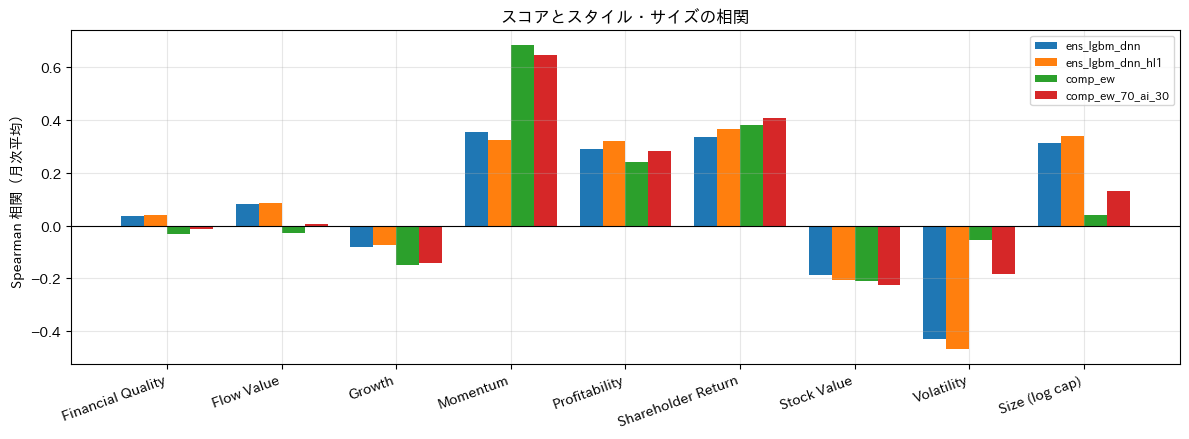

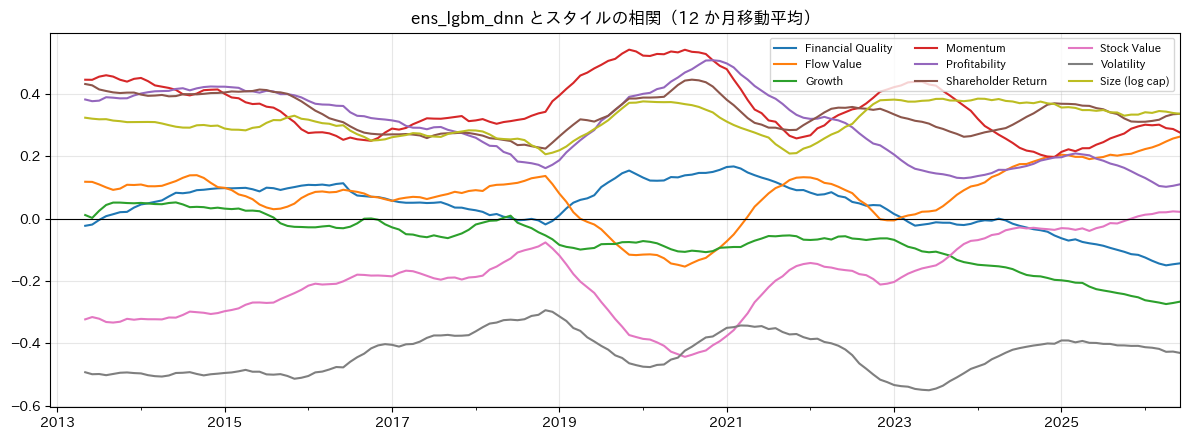

In [4]:
def row_corr(a: pd.DataFrame, b: pd.DataFrame) -> pd.Series:
    out = {}
    for d in a.index:
        x, y = a.loc[d], b.loc[d]
        m = x.notna() & y.notna()
        out[d] = x[m].rank().corr(y[m].rank()) if m.sum() >= 20 else np.nan
    return pd.Series(out)

corr = {name: pd.DataFrame({s: row_corr(sc, style_score[s]) for s in style_names}) for name, sc in scores.items()}
corr_mean = pd.DataFrame({name: c.mean() for name, c in corr.items()})
corr_t = pd.DataFrame({name: c.mean() / c.std() * np.sqrt(c.count()) for name, c in corr.items()})
print("スタイルとの Spearman 相関（月次平均）")
display(corr_mean.round(3))
print("t 値（月次相関の平均 / 標準誤差）")
display(corr_t.round(1))

fig, ax = plt.subplots(figsize=(12, 4.5))
x = np.arange(len(style_names))
w = 0.8 / len(scores)
for i, name in enumerate(scores):
    ax.bar(x + (i - (len(scores) - 1) / 2) * w, corr_mean[name], width=w, label=name)
ax.axhline(0, color="k", linewidth=0.8)
ax.set_xticks(x, style_names, rotation=20, ha="right")
ax.set_ylabel("Spearman 相関（月次平均）")
ax.set_title("スコアとスタイル・サイズの相関")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

ax = corr[MAIN].rolling(12, min_periods=6).mean().plot(figsize=(12, 4.5))
ax.axhline(0, color="k", linewidth=0.8)
ax.set_title(f"{MAIN} とスタイルの相関（12 か月移動平均）")
ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

## 4. クロスセクション回帰: スコア ~ スタイル + サイズ + セクター

各月、ユニバース内で OLS。R² を「スタイルのみ」「スタイル + サイズ」「スタイル + サイズ + セクター」「サイズ + セクターのみ」で比較し、
標準化ベータは月次推定値の平均と Fama-MacBeth の t 値で示す。

In [5]:
def monthly_regression(y: pd.DataFrame, xs: dict[str, pd.DataFrame], sector_panel: pd.DataFrame | None):
    r2, betas = {}, {}
    for d in y.index:
        yy = y.loc[d]
        X = pd.DataFrame({k: v.loc[d] for k, v in xs.items()})
        if sector_panel is not None:
            dummies = pd.get_dummies(sector_panel.loc[d].dropna().astype(int), prefix="sec", dtype=float)
            X = X.join(dummies, how="left")
        m = yy.notna() & X.notna().all(axis=1)
        if m.sum() < 30:
            continue
        Xm = X[m].to_numpy(dtype=float)
        Xm = np.column_stack([np.ones(len(Xm)), Xm])
        ym = yy[m].to_numpy(dtype=float)
        beta, *_ = np.linalg.lstsq(Xm, ym, rcond=None)
        resid = ym - Xm @ beta
        r2[d] = 1 - resid.var() / ym.var()
        betas[d] = pd.Series(beta[1:1 + len(xs)], index=list(xs))
    return pd.Series(r2), pd.DataFrame(betas).T

specs = {
    "スタイルのみ": (styles, False),
    "スタイル + サイズ": (style_names, False),
    "スタイル + サイズ + セクター": (style_names, True),
    "サイズ + セクターのみ": (["Size (log cap)"], True),
}
r2_tbl, beta_tbl = {}, {}
r2_ts, beta_ts = {}, {}   # 月次の時系列（後のセルで描画）
for name, sc in scores.items():
    for spec, (xs, use_sec) in specs.items():
        r2, b = monthly_regression(sc, {k: style_score[k] for k in xs}, sector if use_sec else None)
        r2_tbl[(name, spec)] = r2.mean()
        r2_ts[(name, spec)] = r2
        if spec == "スタイル + サイズ + セクター":
            beta_tbl[name] = pd.DataFrame({"beta": b.mean(), "t (FM)": b.mean() / b.std() * np.sqrt(b.count())})
            beta_ts[name] = b
r2_df = pd.Series(r2_tbl).unstack()
print("平均 R²")
display(r2_df.round(3))
print("標準化ベータ（スタイル + サイズ + セクター、月次平均と Fama-MacBeth t）")
display(pd.concat(beta_tbl, axis=1).round(2))

平均 R²


,サイズ + セクターのみ,スタイル + サイズ,スタイル + サイズ + セクター,スタイルのみ
comp_ew,0.005,0.695,0.761,0.677
comp_ew_70_ai_30,0.034,0.691,0.731,0.684
ens_lgbm_dnn,0.210,0.516,0.573,0.506
ens_lgbm_dnn_hl1,0.225,0.548,0.602,0.535


標準化ベータ（スタイル + サイズ + セクター、月次平均と Fama-MacBeth t）


ens_lgbm_dnn        ens_lgbm_dnn_hl1         comp_ew         comp_ew_70_ai_30        
                           beta t (FM)             beta  t (FM)    beta  t (FM)             beta  t (FM)
Financial Quality         -0.01  -1.26            -0.01   -2.07   -0.04  -14.64            -0.03  -11.38
Flow Value                 0.34  41.49             0.35   43.11    0.14   30.80             0.22   44.26
Growth                    -0.11 -20.81            -0.10  -19.58   -0.25  -73.36            -0.23  -59.50
Momentum                   0.34  51.17             0.30   49.29    0.81  254.78             0.74  201.07
Profitability              0.06   7.73             0.08    9.62    0.11   26.83             0.11   20.34
Shareholder Return         0.15  34.22             0.17   38.24    0.26   95.56             0.25   90.90
Stock Value               -0.23 -32.67            -0.25  -35.62   -0.10  -21.80            -0.15  -31.55
Volatility                -0.38 -89.06            -0.39 -100.18   -0.12  -25.81            -0.22  -50.77
Size (log cap)             0.08  15.27             0.09   20.01   -0.14  -23.60            -0.09  -16.91

### 回帰の時系列

R²（スタイル + サイズ + セクター）の推移と、標準化ベータの推移（12 か月移動平均）。ティルトが期間を通じて安定しているか、
特定の局面で強まっているかを確認する。

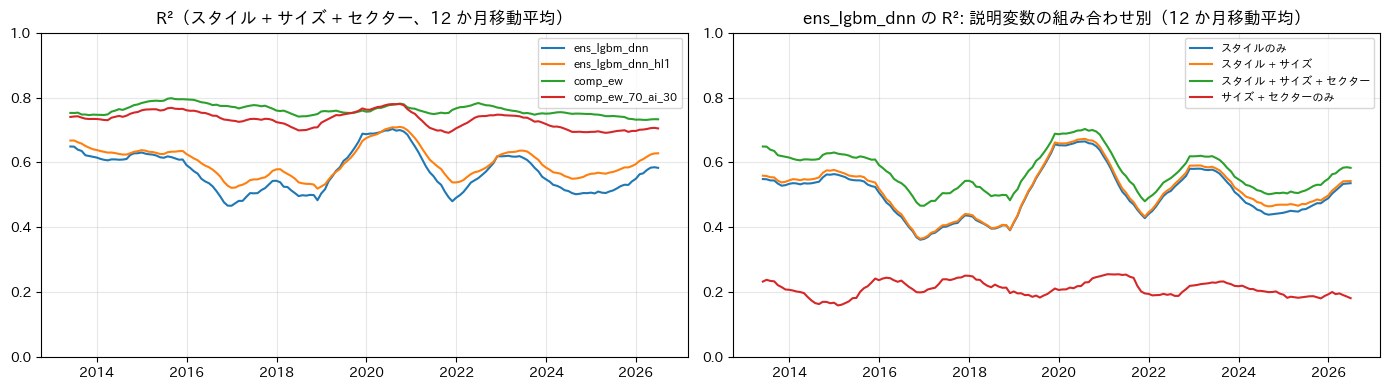

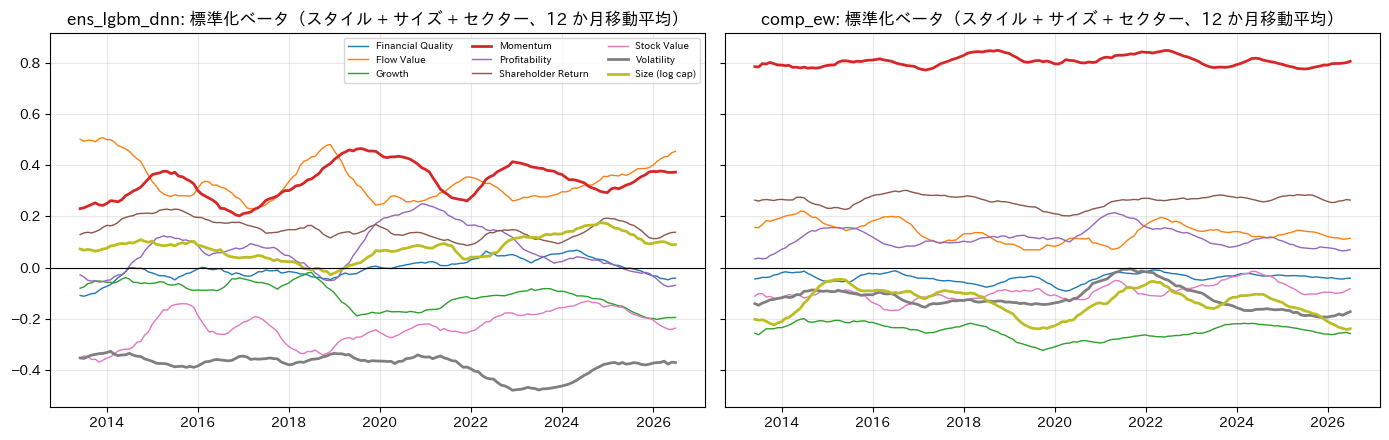

ベータの年別平均（ens_lgbm_dnn）


,Financial Quality,Flow Value,Growth,Momentum,Profitability,Shareholder Return,Stock Value,Volatility,Size (log cap)
2012,-0.08,0.55,-0.03,0.21,-0.04,0.13,-0.39,-0.39,0.09
2013,-0.07,0.50,-0.06,0.25,-0.05,0.16,-0.35,-0.33,0.08
2014,-0.02,0.34,-0.06,0.36,0.10,0.21,-0.22,-0.37,0.10
2015,-0.01,0.31,-0.09,0.30,0.09,0.20,-0.19,-0.38,0.09
2016,-0.03,0.25,-0.04,0.21,0.08,0.17,-0.21,-0.35,0.04
2017,-0.02,0.34,-0.06,0.30,0.05,0.15,-0.31,-0.38,0.02
2018,-0.04,0.46,-0.10,0.42,-0.05,0.12,-0.31,-0.34,-0.02
2019,0.00,0.25,-0.18,0.44,0.18,0.16,-0.25,-0.37,0.06
2020,0.02,0.26,-0.17,0.38,0.25,0.13,-0.22,-0.35,0.08
2021,0.03,0.35,-0.12,0.27,0.16,0.09,-0.25,-0.40,0.04


In [6]:
SPEC_FULL = "スタイル + サイズ + セクター"
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for name in scores:
    s = r2_ts[(name, SPEC_FULL)]
    axes[0].plot(s.index, s.rolling(12, min_periods=6).mean(), label=name)
axes[0].set_ylim(0, 1)
axes[0].set_title(f"R²（{SPEC_FULL}、12 か月移動平均）")
axes[0].legend(fontsize=8)
for spec in specs:
    s = r2_ts[(MAIN, spec)]
    axes[1].plot(s.index, s.rolling(12, min_periods=6).mean(), label=spec)
axes[1].set_ylim(0, 1)
axes[1].set_title(f"{MAIN} の R²: 説明変数の組み合わせ別（12 か月移動平均）")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, name in zip(axes, [MAIN, "comp_ew"]):
    b = beta_ts[name].rolling(12, min_periods=6).mean()
    for col in style_names:
        ax.plot(b.index, b[col], label=col, linewidth=2.0 if col in ("Volatility", "Size (log cap)", "Momentum") else 1.0)
    ax.axhline(0, color="k", linewidth=0.8)
    ax.set_title(f"{name}: 標準化ベータ（{SPEC_FULL}、12 か月移動平均）")
axes[0].legend(fontsize=7, ncol=3)
plt.tight_layout()
plt.show()

print("ベータの年別平均（" + MAIN + "）")
b = beta_ts[MAIN]
display(b.groupby(b.index.year).mean().round(2))

## 5. 個別ファクターとの相関（上位 / 下位）

In [7]:
fac_corr = pd.DataFrame({f: row_corr(scores[MAIN], core_z[f]) for f in core_z}).mean().sort_values()
fac_tbl = pd.DataFrame({"corr": fac_corr, "style": pd.Series(style_of)}).dropna()
print(f"{MAIN} と各 core ファクターの相関: 上位 12 / 下位 12")
display(pd.concat([fac_tbl.tail(12).iloc[::-1], fac_tbl.head(12)]).round(3))
print("comp_ew との比較（同じファクター）")
fac_corr_c = pd.DataFrame({f: row_corr(scores["comp_ew"], core_z[f]) for f in core_z}).mean()
both = pd.DataFrame({MAIN: fac_corr, "comp_ew": fac_corr_c, "style": pd.Series(style_of)}).dropna()
display(both.reindex(both[MAIN].abs().sort_values(ascending=False).index).head(15).round(3))

ens_lgbm_dnn と各 core ファクターの相関: 上位 12 / 下位 12


,corr,style
zscore,0.227,Financial Quality
xfin_sp,-0.150,Financial Quality
xfin_cf,-0.301,Financial Quality
xfin_bs,-0.313,Financial Quality
vola60,-0.506,Volatility
tover,-0.298,Momentum
tl_ta,-0.097,Financial Quality
tdint,-0.022,Financial Quality
td_ta,-0.217,Financial Quality
ta_to,0.207,Financial Quality


comp_ew との比較（同じファクター）


,ens_lgbm_dnn,comp_ew,style
rev3r,0.525,0.659,Momentum
rev3p,0.511,0.653,Momentum
doe,0.509,0.385,Shareholder Return
vola60,-0.506,-0.106,Volatility
roe_est,0.382,0.363,Profitability
roe_act,0.371,0.240,Profitability
dp_act,0.370,0.230,Flow Value
rev1r,0.367,0.575,Momentum
npop,0.363,0.330,Shareholder Return
csi,-0.360,-0.250,Shareholder Return


## 6. Q5 ポートフォリオのスタイル露出

Q5（最上位 20%、等ウェイト）メンバーのスタイルスコア平均 − ユニバース平均（z 単位）。

,ens_lgbm_dnn,ens_lgbm_dnn_hl1,comp_ew,comp_ew_70_ai_30
Financial Quality,0.062,0.071,-0.068,-0.033
Flow Value,0.042,0.037,-0.032,-0.007
Growth,-0.094,-0.089,-0.216,-0.197
Momentum,0.516,0.478,0.941,0.891
Profitability,0.394,0.448,0.299,0.366
Shareholder Return,0.419,0.463,0.497,0.535
Stock Value,-0.303,-0.341,-0.267,-0.306
Volatility,-0.489,-0.533,0.032,-0.151
Size (log cap),0.373,0.422,-0.029,0.085


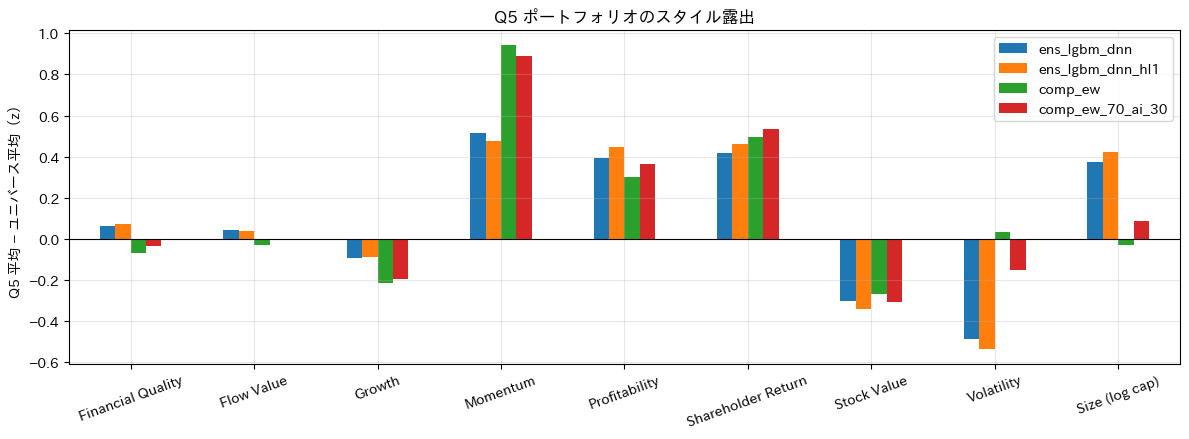

In [8]:
rows = {}
for name, sc in scores.items():
    q = quantile_analysis(sc, store.returns("GEMLT", "rtn", START, 202607), univ, n_quantiles=5)
    top = q.weights[q.top].notna()
    rows[name] = {s: (style_score[s].where(top).mean(axis=1) - style_score[s].mean(axis=1)).mean() for s in style_names}
exp_tbl = pd.DataFrame(rows)
display(exp_tbl.round(3))
ax = exp_tbl.plot.bar(figsize=(12, 4.5))
ax.axhline(0, color="k", linewidth=0.8)
ax.set_ylabel("Q5 平均 − ユニバース平均（z）")
ax.set_title("Q5 ポートフォリオのスタイル露出")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## 7. スタイルで説明されない残差スコアの IC

スコアをスタイル + サイズ + セクターに月次回帰した残差（再 Blom 化）の IC を、元のスコアの IC と比べる。
残差の IC が元と同程度なら、スコアの情報はスタイルに還元されない銘柄固有のもの。

In [9]:
def residualize(y: pd.DataFrame, xs: dict[str, pd.DataFrame], sector_panel: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(np.nan, index=y.index, columns=y.columns)
    for d in y.index:
        yy = y.loc[d]
        X = pd.DataFrame({k: v.loc[d] for k, v in xs.items()})
        X = X.join(pd.get_dummies(sector_panel.loc[d].dropna().astype(int), prefix="sec", dtype=float), how="left")
        m = yy.notna() & X.notna().all(axis=1)
        if m.sum() < 30:
            continue
        Xm = np.column_stack([np.ones(int(m.sum())), X[m].to_numpy(dtype=float)])
        beta, *_ = np.linalg.lstsq(Xm, yy[m].to_numpy(dtype=float), rcond=None)
        out.loc[d, m[m].index] = yy[m].to_numpy() - Xm @ beta
    return blom(out)

rtn = store.returns("GEMLT", "rtn", START, 202607)
srtn = store.returns("GEMLT", "srtn", START, 202607)
rows = {}
for name, sc in scores.items():
    resid = residualize(sc, {k: style_score[k] for k in style_names}, sector)
    for kind, r in [("drtn", rtn), ("srtn", srtn)]:
        fwd = forward_returns(r, 1)
        ic_raw = ic_summary(information_coefficient(sc, fwd, univ))
        ic_res = ic_summary(information_coefficient(resid, fwd, univ))
        rows[(name, kind)] = {"IC 元": ic_raw["mean"], "ICIR 元": ic_raw["icir"], "IC 残差": ic_res["mean"], "ICIR 残差": ic_res["icir"], "残差/元": ic_res["mean"] / ic_raw["mean"]}
res_tbl = pd.DataFrame(rows).T
res_tbl.index.names = ["スコア", "リターン"]
display(res_tbl.round(3))

IC 元  ICIR 元  IC 残差  ICIR 残差   残差/元
スコア              リターン                                      
ens_lgbm_dnn     drtn  0.078   0.551  0.047    0.724  0.604
                 srtn  0.060   0.556  0.047    0.793  0.785
ens_lgbm_dnn_hl1 drtn  0.074   0.497  0.041    0.607  0.553
                 srtn  0.054   0.478  0.039    0.645  0.723
comp_ew          drtn  0.056   0.490  0.031    0.427  0.544
                 srtn  0.033   0.320  0.023    0.335  0.697
comp_ew_70_ai_30 drtn  0.070   0.548  0.042    0.599  0.597
                 srtn  0.046   0.440  0.036    0.564  0.794

## 所見

評価期間 2012-12〜2026-06（163 か月）、スタイルは `alpha/LIST.md` の core 表（8 スタイル・100 ファクター）。

**スタイル・サイズとの相関（月次 Spearman の平均）**

| | ens_lgbm_dnn | comp_ew | 差の意味 |
| --- | --- | --- | --- |
| Volatility | **−0.43** | −0.05 | AI は低ボラ銘柄を強く選好。comp_ew はほぼ中立 |
| Size (log cap) | **+0.31** | +0.04 | AI は大型に寄る。comp_ew はサイズ中立化済み |
| Momentum | +0.35 | **+0.68** | comp_ew はモメンタム（リビジョン + mom12_1）が支配的 |
| Shareholder Return | +0.34 | +0.38 | 両者同程度（doe / npop / dp） |
| Profitability | +0.29 | +0.24 | 両者同程度 |
| Stock Value | −0.19 | −0.21 | 両者とも B/P 低（割高）側 |
| Growth | −0.08 | −0.15 | 両者とも資産成長が低い側（規律） |
| Flow Value | +0.08 | −0.03 | AI は E/P・D/P 側にやや寄る |

- AI スコアの最大のティルトは **低ボラティリティ**（`vola60` との相関 −0.51）と **サイズ**（+0.31）。
  この 2 つは comp_ew に無いもので、`03_bax_results` で見た「BM 加重平均 +0.80」「制約下でアルファが吸収される」の正体。
- 個別ファクターでは `rev3r` / `rev3p`（0.52）、`doe`（0.51）、`vola60`（−0.51）、`roe_est`（0.38）、`dp_act`（0.37）が上位。
  AI はリビジョン・還元・収益性という comp_ew と同じ素材を使いつつ、comp_ew が中立化しているボラとサイズを取り込んでいる。

**クロスセクション回帰の R²**

| | スタイルのみ | + サイズ | + セクター | サイズ + セクターのみ |
| --- | --- | --- | --- | --- |
| ens_lgbm_dnn | 0.51 | 0.52 | **0.57** | **0.21** |
| comp_ew | 0.68 | 0.70 | 0.76 | 0.01 |

- AI スコアの分散の 57% がスタイル + サイズ + セクターで説明される（comp_ew は構成上 76%）。
  サイズ + セクターだけで 21%（comp_ew は 1%）。標準化ベータは Volatility −0.38、Flow Value +0.34、Momentum +0.34、Stock Value −0.23。
- Fama-MacBeth の t 値はいずれも大きく、ティルトは全期間を通じて安定（12 か月移動平均でも符号は変わらない）。

**Q5 ポートフォリオのスタイル露出（Q5 平均 − ユニバース平均、z）**

- AI の Q5 は Momentum +0.52、Shareholder Return +0.42、Profitability +0.39、Size +0.37、Volatility −0.49。
- comp_ew の Q5 は Momentum +0.94 が突出し、Size −0.03、Volatility +0.03 で中立。

**スタイルで説明されない残差の IC**

| | IC 元 | ICIR 元 | IC 残差 | ICIR 残差 | 残差 / 元 |
| --- | --- | --- | --- | --- | --- |
| ens_lgbm_dnn（drtn） | 0.078 | 0.55 | 0.047 | **0.72** | 60% |
| ens_lgbm_dnn（srtn） | 0.060 | 0.56 | 0.047 | **0.79** | 79% |
| comp_ew（drtn） | 0.056 | 0.49 | 0.031 | 0.43 | 54% |

- AI の IC の 6 割はスタイル・サイズ・セクターに還元されない銘柄固有の情報で、**残差にすると ICIR はむしろ上がる**（0.55 → 0.72）。
  固有リターンに対しては 8 割が残る。スタイル部分（低ボラ・サイズ）は IC には寄与するが変動が大きく、ICIR を下げている。
- comp_ew は残差の ICIR が下がる（0.49 → 0.43）。comp_ew の情報はスタイル（モメンタム）そのもの。

**判断**

1. AI スコアは「低ボラ + 大型 + モメンタム + 還元 + 収益性」のスタイル複合に、スタイルで説明できない固有情報（IC 0.047、ICIR 0.72）が乗ったもの。
2. 最適化で吸収されていたのは低ボラとサイズのティルト。これらは制約下（対 BM ±3%、リスクインデックス ±2sd）で実現できず、
   かつ ICIR を下げているので、**除いた方がよい成分**。
3. 次のステップは AI スコアの中立化版（`ens_lgbm_dnn_neu`: 各月、Blom → サイズ・ボラ（必要ならセクター）への回帰残差 → 再 Blom）を作り、
   `02`（制約なし）と `03`（最適化）の両方で comp_ew との複合を再評価すること。残差 ICIR の高さから、制約下での実現率改善が見込める。
   中立化は `scripts/build_blend.py` と同様の小さなスクリプトで実装できる（入力: `my_ai/ens_lgbm_dnn`、`attributes/gics`、`core/vola60`、`univ/`）。